In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import os
os.chdir('./raw_data/')

In [10]:
# age_below_65_df 林醫師給的那份裡面是空的，所以要用建蒼之前整理過放在 one drive 上的 data
# age_below_65_df = pd.read_excel('Stroke-cleared-with subgroup.xlsx', sheet_name='age<65')
age_between_65_80_df = pd.read_excel('Stroke-cleared-with subgroup.xlsx', sheet_name='age65-80')
age_over_80_df = pd.read_excel('Stroke-cleared-with subgroup.xlsx', sheet_name='age>80')

age_below_65_df = pd.read_csv('age_below_65.csv')
# age_between_65_80_df = pd.read_csv('age_between_65_80.csv')
# age_over_80_df = pd.read_csv('age_over_80.csv')

In [12]:
all_df = [age_below_65_df, age_between_65_80_df, age_over_80_df]
for i in range(len(all_df)):
    all_df[i]=all_df[i].rename(columns={"LDL ": "LDL"})

In [76]:
categorical_features = ['sex','tPA(0/1)','EVT(0/1)','HTN(0/1)','DM(0/1)','Dyslipidemia(0/1)','Af(0/1)','smoking(Y/N/Q)', 'MRS']

In [77]:
cont_features = ['age', 'HLOS', 'NIHSS', 'LDL', 'cholesterol', 'TG', 'Cre', 'SGPT', 'HbA1c']

In [15]:
label = 'Second_Stroke'

In [16]:
all_df = [age_below_65_df, age_between_65_80_df, age_over_80_df]
map_names = ['Age < 65', 'Age in Between 65 and 80', 'Age > 80']

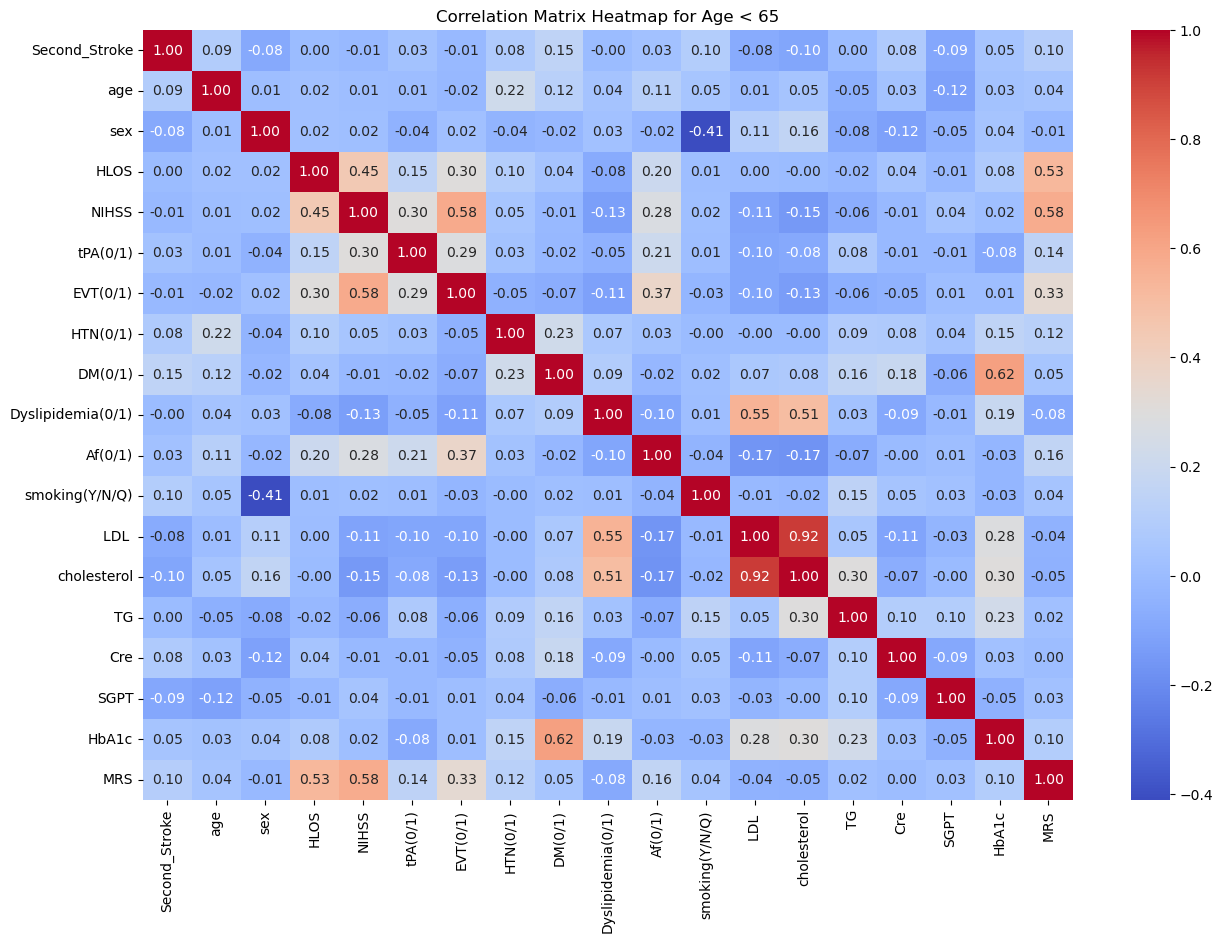

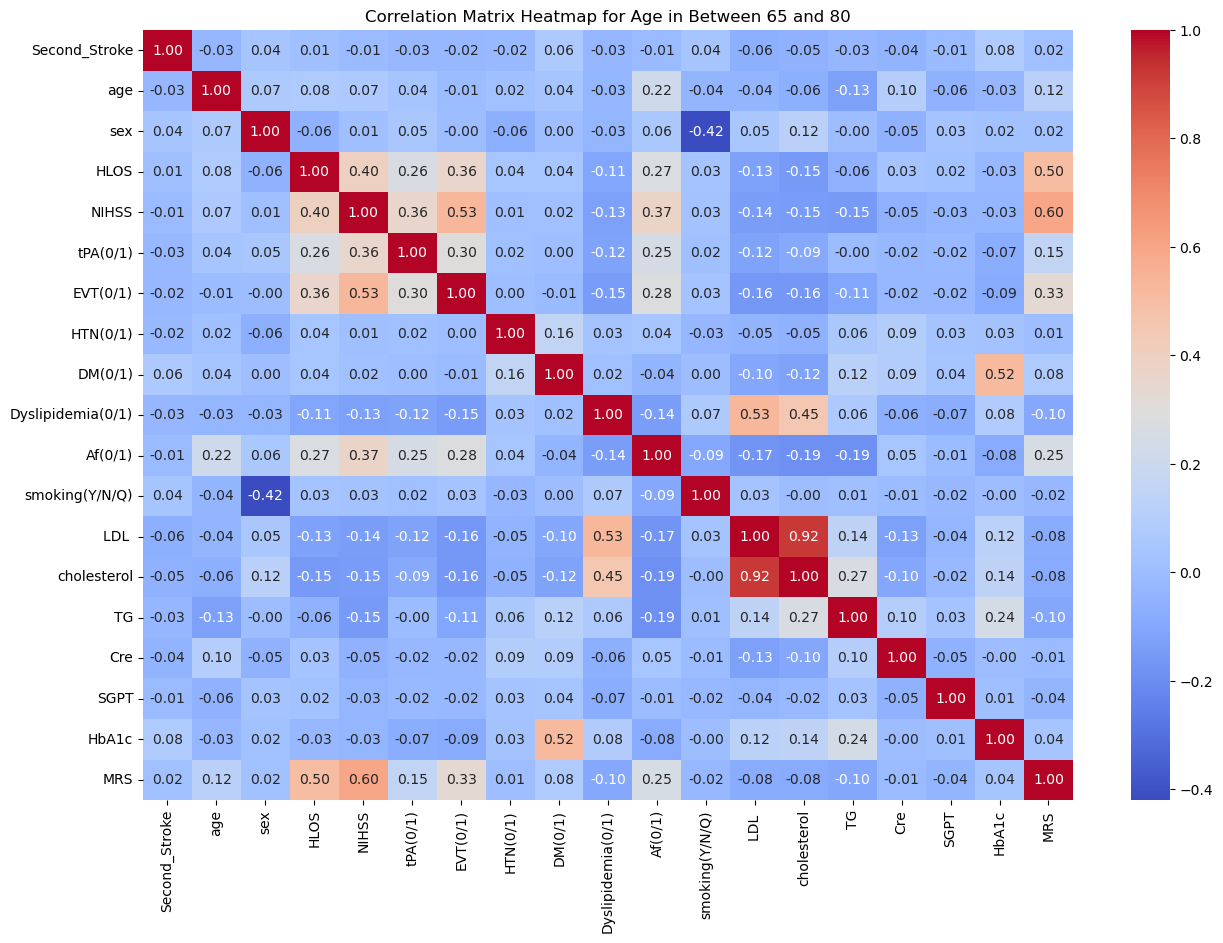

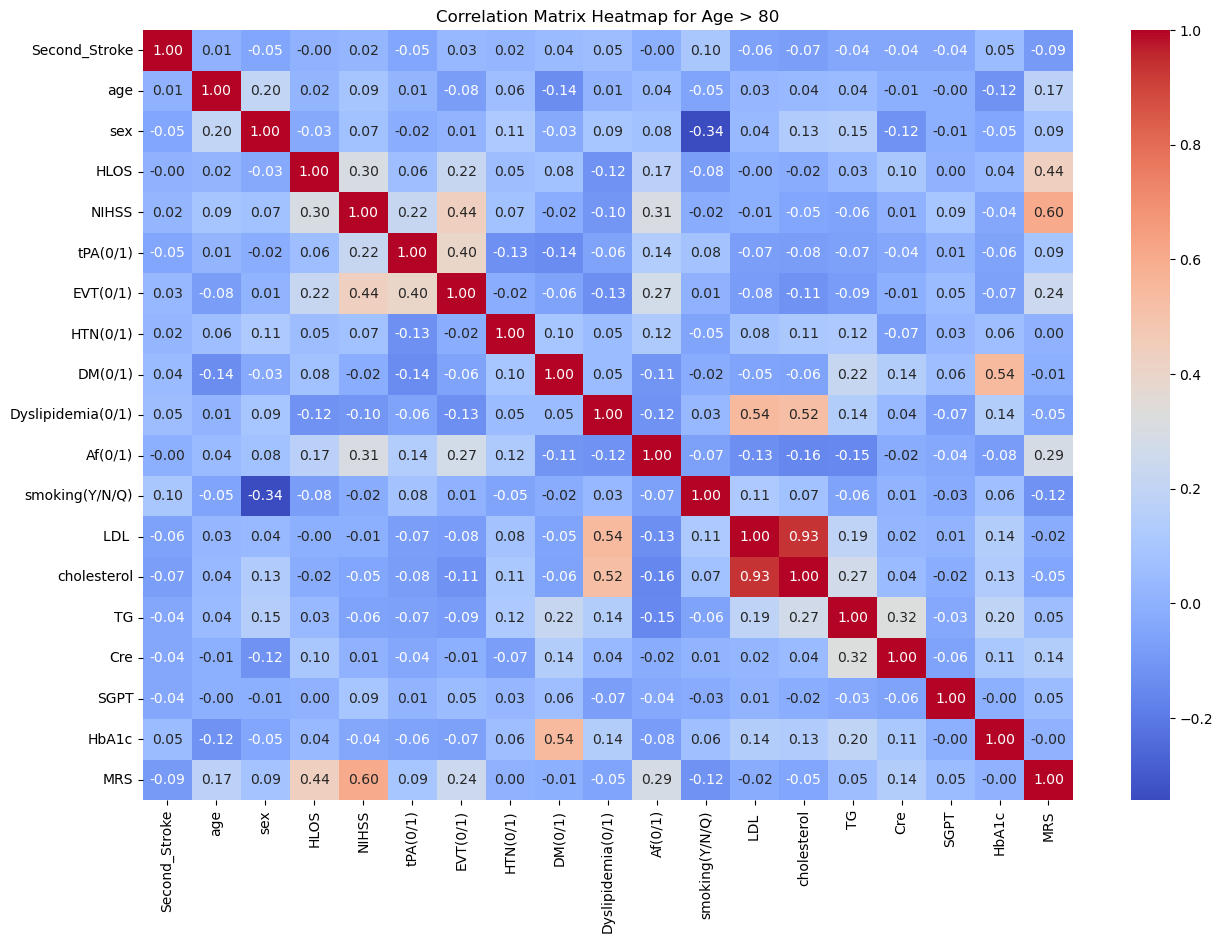

In [17]:
for i in range(len(all_df)):
    
    correlation_matrix = all_df[i].corr()
    
    # Using the correlation_matrix from above
    plt.figure(figsize=(15, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix Heatmap for ' + map_names[i])
    plt.show()

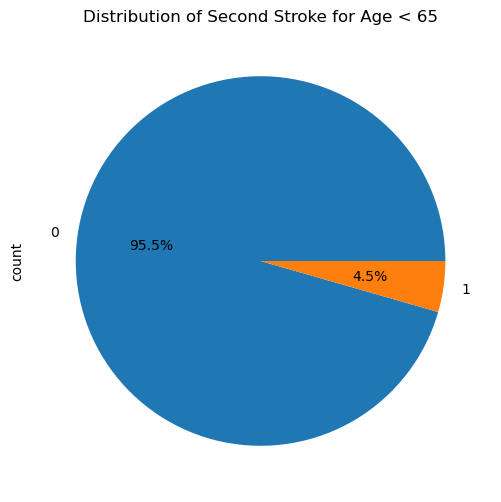

In [18]:
category_counts = age_below_65_df['Second_Stroke'].value_counts()
plot = category_counts.plot.pie(autopct='%1.1f%%', figsize=(6, 6), title='Distribution of Second Stroke for Age < 65')

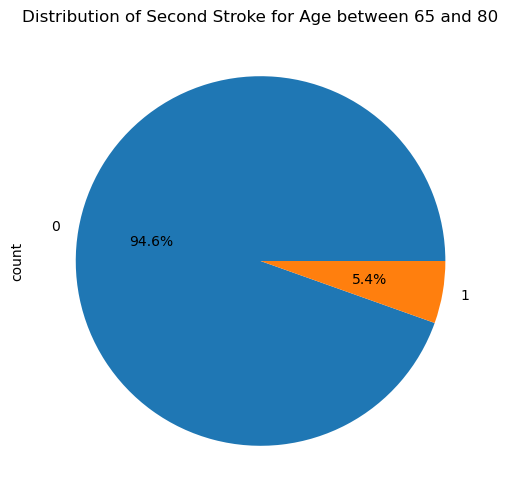

In [19]:
category_counts = age_between_65_80_df['Second_Stroke'].value_counts()
# Plot the pie chart
plot = category_counts.plot.pie(autopct='%1.1f%%', figsize=(6, 6), title='Distribution of Second Stroke for Age between 65 and 80')

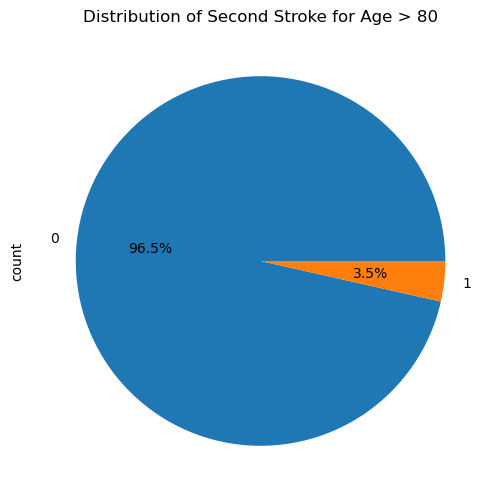

In [20]:
category_counts = age_over_80_df['Second_Stroke'].value_counts()
# Plot the pie chart
plot = category_counts.plot.pie(autopct='%1.1f%%', figsize=(6, 6), title='Distribution of Second Stroke for Age > 80')

In [21]:
print(age_below_65_df['Second_Stroke'].value_counts())
print(age_between_65_80_df['Second_Stroke'].value_counts())
print(age_over_80_df['Second_Stroke'].value_counts())

Second_Stroke
0    472
1     22
Name: count, dtype: int64
Second_Stroke
0    695
1     40
Name: count, dtype: int64
Second_Stroke
0    246
1      9
Name: count, dtype: int64


In [78]:
# for i in range(len(categorical_features)):
#     # Count each category
#     young_counts = age_below_65_df[categorical_features[i]].value_counts().sort_index()
#     middle_counts = age_between_65_80_df[categorical_features[i]].value_counts().sort_index()
#     old_counts = age_over_80_df[categorical_features[i]].value_counts().sort_index()

#     # Make sure categories are aligned
#     categories = sorted(set(young_counts.index) | set(middle_counts.index) | set(old_counts.index))
#     young = [young_counts.get(cat, 0) for cat in categories]
#     middle = [middle_counts.get(cat, 0) for cat in categories]
#     old = [old_counts.get(cat, 0) for cat in categories]

#     # Define bar positions
#     x = np.arange(len(categories))
#     width = 0.25  # narrower since 3 groups

#     # Plot side-by-side
#     plt.figure(figsize=(10, 6))
#     plt.bar(x - width, young, width=width, color='lightcoral', alpha=0.7, label='Age < 65')
#     plt.bar(x, middle, width=width, color='gold', alpha=0.7, label='Age Between 65 and 80')
#     plt.bar(x + width, old, width=width, color='skyblue', alpha=0.7, label='Age > 85')
    
#     # Formatting
#     plt.xticks(x, categories)
#     plt.xlabel(categorical_features[i])
#     plt.ylabel('Count')
#     plt.title(categorical_features[i] + ' Distribution Across Age Groups')
#     plt.legend(title='Age Group')
#     plt.tight_layout()
#     plt.show()

In [80]:
age_below_65_df['age_group'] = 'young'
age_between_65_80_df['age_group'] = 'middle'
age_over_80_df['age_group'] = 'old'
df_combined = pd.concat([age_below_65_df, age_between_65_80_df, age_over_80_df])

In [81]:
df_combined = df_combined.rename(columns={"LDL ": "LDL"})

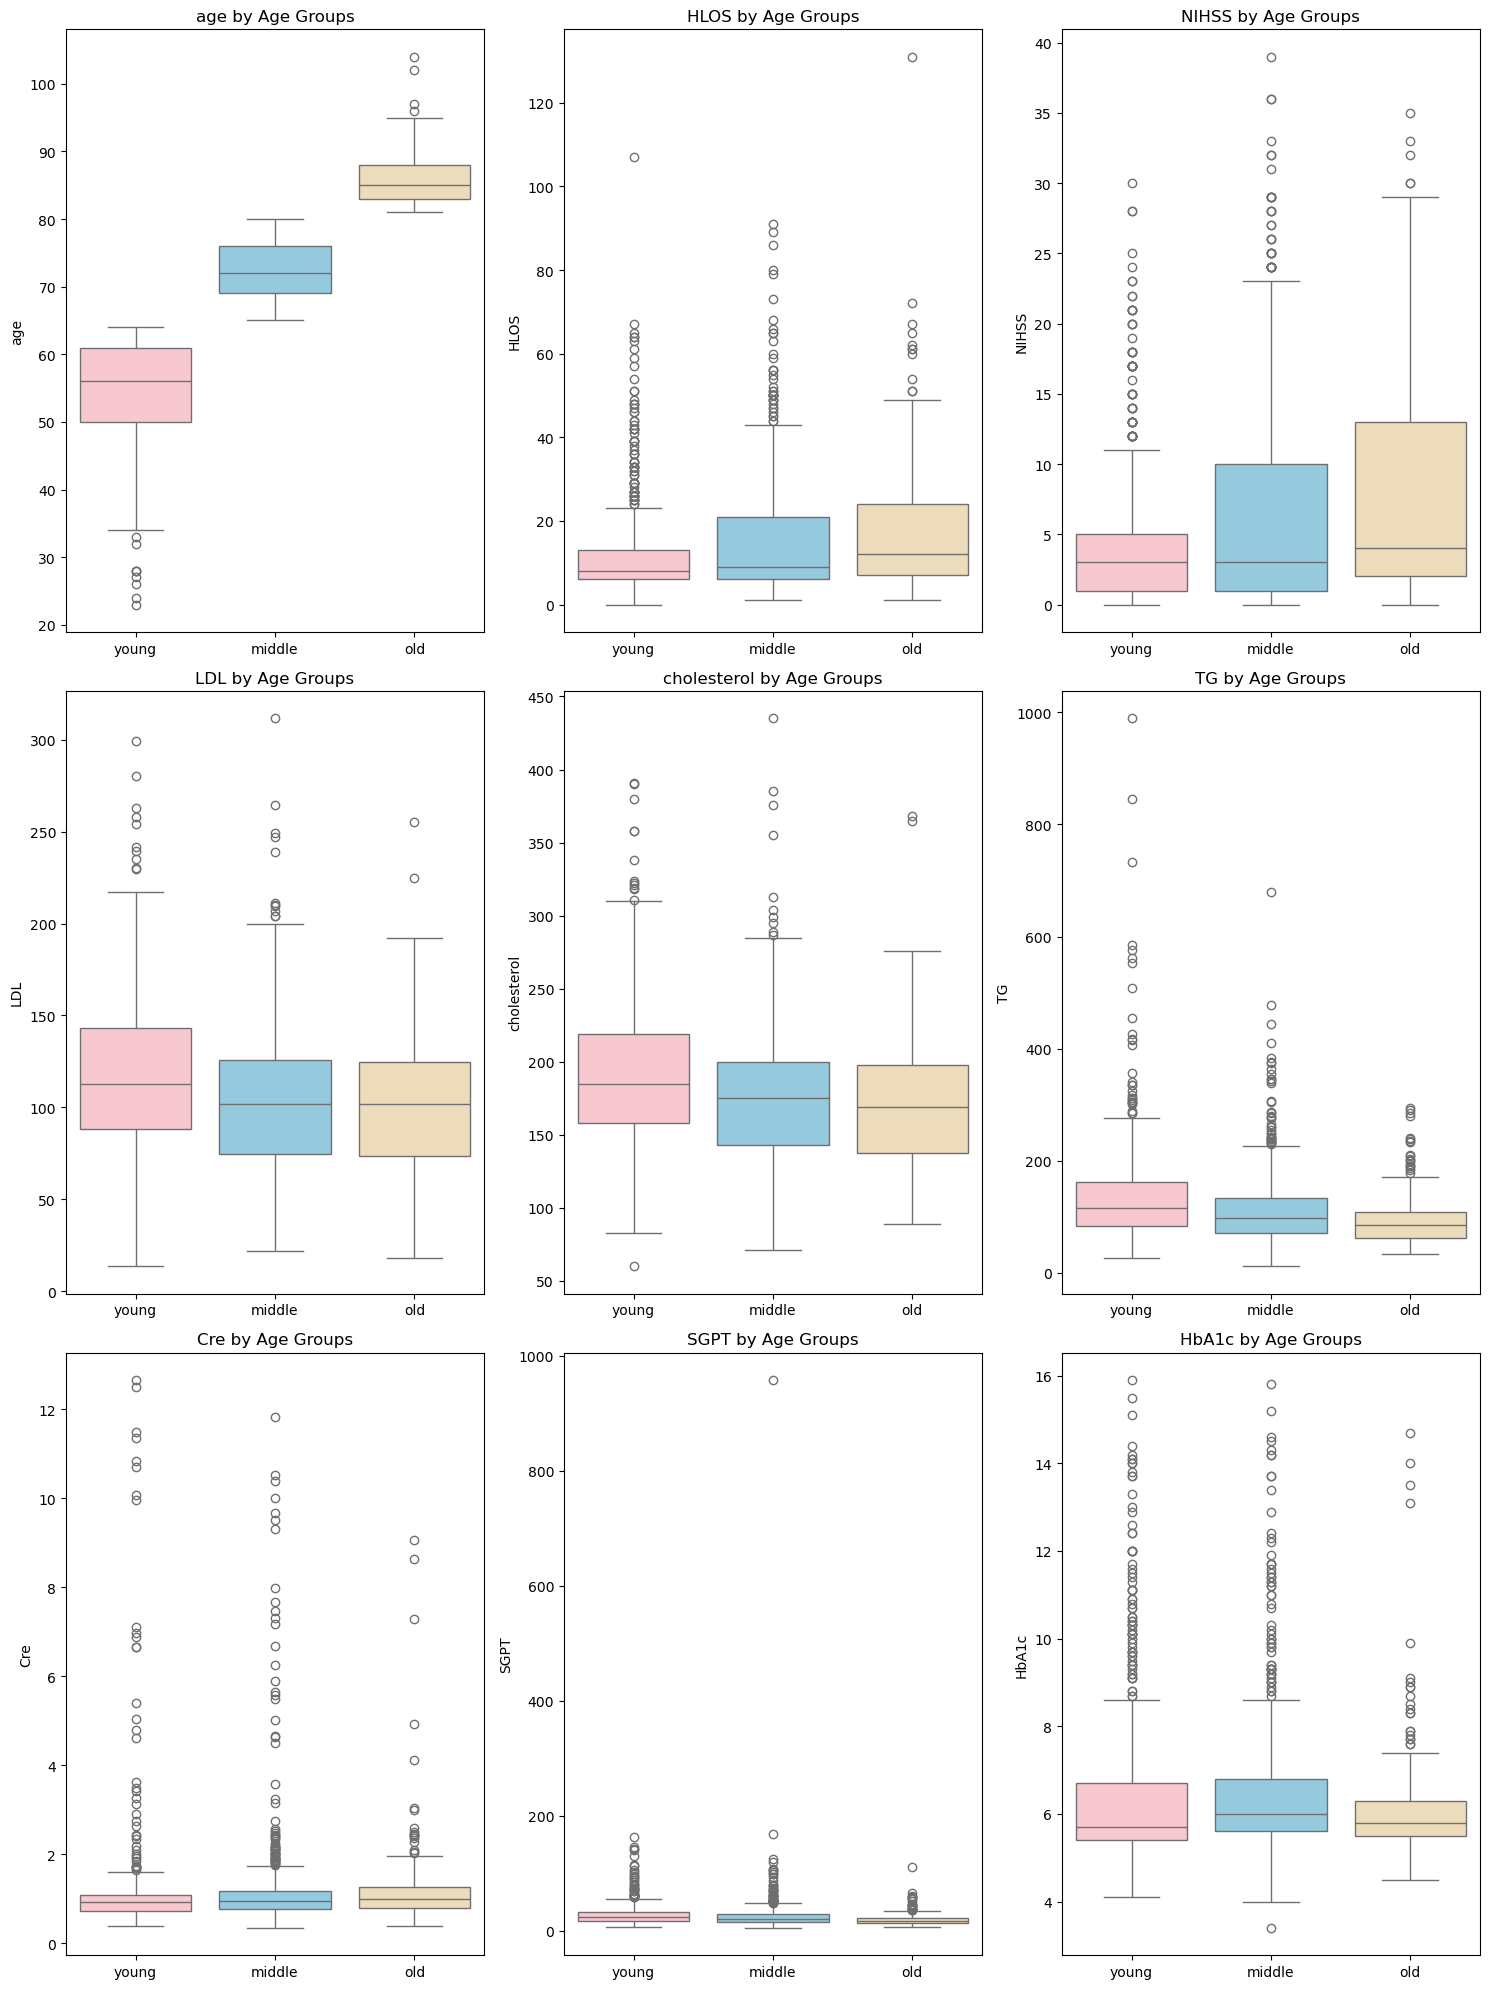

In [86]:
features = cont_features
fig, axes = plt.subplots(3, 3, figsize=(15, 20))

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=df_combined, x='age_group', y=feature, hue='age_group', palette=['pink', 'skyblue', 'wheat'], ax=ax)
    ax.set_title(f'{feature} by Age Groups')
    ax.set_xlabel('')
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

In [126]:
# create summary function
def summary_stats(x):
    return pd.Series({
        'Mean': x.mean(),
        'Std': x.std(),
        'Median': x.median(),
        'Min': x.min(),
        'Max': x.max()
    })

features = cont_features

# apply by group
summary_table = (
    df_combined
    .groupby('age_group')[features]
    .apply(lambda df: df.apply(summary_stats))
    .swaplevel(axis=0)
    .sort_index(level=0)
)

# round and print
summary_table = summary_table.round(2)
display(summary_table)

/var/folders/v7/p572dhnj3hnghq8_3m4f2xpc0000gn/T/ipykernel_53737/3420205807.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('age_group')[features]


age    HLOS  NIHSS     LDL  cholesterol      TG    Cre  \
       age_group                                                              
Max    young       64.00  107.00  30.00  299.40       391.00  989.00  12.65   
       middle      80.00   91.00  39.00  311.50       435.00  680.00  11.81   
       old        104.00  131.00  35.00  255.00       368.00  295.00   9.06   
Mean   young       54.28   12.51   4.52  116.70       190.42  139.29   1.23   
       middle      72.42   15.31   6.58  103.26       175.31  113.24   1.21   
       old         85.76   17.69   7.85  101.60       172.65   94.79   1.19   
Median young       56.00    8.00   3.00  112.95       185.00  115.00   0.92   
       middle      72.00    9.00   3.00  102.00       175.00   98.00   0.95   
       old         85.00   12.00   4.00  101.70       169.00   85.00   1.00   
Min    young       23.00    0.00   0.00   13.70        60.00   26.00   0.39   
       middle      65.00    1.00   0.00   22.00        71.00   12.00   0.35   
       old         81.00    1.00   0.00   18.00        89.00   34.00   0.39   
Std    young        7.94   12.80   5.41   42.39        50.22   98.87   1.51   
       middle       4.51   14.26   7.47   38.32        45.27   64.63   1.22   
       old          4.09   15.92   8.47   37.71        45.70   47.08   0.95   

                    SGPT  HbA1c  
       age_group                 
Max    young      163.00  15.90  
       middle     958.00  15.80  
       old        111.00  14.70  
Mean   young       29.20   6.58  
       middle      26.15   6.50  
       old         20.36   6.14  
Median young       23.50   5.70  
       middle      21.00   6.00  
       old         17.00   5.80  
Min    young        6.00   4.10  
       middle       5.00   3.40  
       old          7.00   4.50  
Std    young       20.42   2.10  
       middle      38.00   1.64  
       old         11.44   1.29

#### 為了要比較不同年齡族群之間的各個 continous feature 是否有 significant differences 

#### 所以要先 test for normality for continuous features 

#### 才知道下一步的比較該用 One-way ANOVA (某 feature 在 all groups all have approximately normal distributions) 還是 Kruskal–Wallis H test (Any group non-normal)

In [88]:
# Use the Shapiro–Wilk test (good for n < 5000) or Kolmogorov–Smirnov for large samples. 
# In our case, we have a small sample size so we use the Shapiro–Wilk test.

from scipy.stats import shapiro

normality_results = []
for feature in cont_features:
    for group in ['young', 'middle', 'old']:
        data = df_combined.loc[df_combined['age_group'] == group, feature].dropna()
        if len(data) >= 3:  # Shapiro requires at least 3 data points
            stat, p = shapiro(data)
            normality_results.append({
                'Feature': feature,
                'Age Group': group,
                'W-statistic': stat,
                'p-value': p,
                'normal_or_not': int(p > 0.05)
            })

normality_df = pd.DataFrame(normality_results)
print(normality_df)


        Feature Age Group  W-statistic       p-value  normal_or_not
0           age     young     0.917370  8.461408e-16              0
1           age    middle     0.948456  2.498995e-15              0
2           age       old     0.906042  1.522933e-11              0
3          HLOS     young     0.676307  1.260253e-29              0
4          HLOS    middle     0.767110  5.606208e-31              0
5          HLOS       old     0.774564  1.935104e-18              0
6         NIHSS     young     0.756153  2.235298e-26              0
7         NIHSS    middle     0.802249  5.353282e-29              0
8         NIHSS       old     0.832749  6.897548e-16              0
9           LDL     young     0.976377  3.641153e-07              0
10          LDL    middle     0.969612  3.176439e-11              0
11          LDL       old     0.979593  1.006706e-03              0
12  cholesterol     young     0.971958  4.032036e-08              0
13  cholesterol    middle     0.967516  1.055087

### Interpretation:

#### p > 0.05 == normal_or_not = 1 → cannot reject normality (≈ normally distributed)

#### p ≤ 0.05 == normal_or_not = 0 → not normal → use non-parametric test later.

In [91]:
from scipy.stats import f_oneway, kruskal

anova_results = []
for feature in cont_features:
    groups = [df_combined.loc[df_combined['age_group'] == g, feature].dropna()
              for g in ['young', 'middle', 'old']]
    # Decide which test to use based on normality
    is_normal = all(
        normality_df.query("Feature == @feature")["p-value"] > 0.05
    )
    if is_normal:
        stat, p = f_oneway(*groups)
        test_name = "ANOVA"
    else:
        stat, p = kruskal(*groups)
        test_name = "Kruskal-Wallis"

    anova_results.append({'Feature': feature, 'Test': test_name, 'Statistic': stat, 'p-value': p})

anova_df = pd.DataFrame(anova_results).round(4)
print(anova_df)

       Feature            Test  Statistic  p-value
0          age  Kruskal-Wallis  1241.3958   0.0000
1         HLOS  Kruskal-Wallis    37.6117   0.0000
2        NIHSS  Kruskal-Wallis    26.8920   0.0000
3          LDL  Kruskal-Wallis    37.8159   0.0000
4  cholesterol  Kruskal-Wallis    35.1903   0.0000
5           TG  Kruskal-Wallis    74.0674   0.0000
6          Cre  Kruskal-Wallis    11.5118   0.0032
7         SGPT  Kruskal-Wallis    68.4579   0.0000
8        HbA1c  Kruskal-Wallis    16.2991   0.0003


### Interpretation:

#### H-statistic: measures how different the rank distributions are among groups (larger = greater difference).

#### p-value: probability that the observed difference in medians occurred by chance if all groups come from the same population.

### Decision rule:

#### If p < 0.05, reject the null hypothesis → there is a statistically significant difference in median values among the age groups.

#### If p ≥ 0.05, fail to reject the null → no evidence of a difference.

### 發現結果都 < 0.05, what to do after a significant result?

#### Kruskal–Wallis tells you that at least one group differs, but not which ones differ.
#### To find out which specific pairs are different, perform post-hoc pairwise comparisons using the Dunn test with Bonferroni or Holm correction for multiple comparisons:

In [93]:
#!pip3 install scikit_posthocs

In [96]:
import scikit_posthocs as sp

# 指定順序
df_combined['age_group'] = pd.Categorical(
    df_combined['age_group'],
    categories=['young', 'middle', 'old'],
    ordered=True
)

# 然後跑 Dunn test
for feature in cont_features:
    result = sp.posthoc_dunn(
        df_combined,
        val_col=feature,
        group_col='age_group',
        p_adjust='bonferroni'
    ).round(4)
    print(f"\n=== Dunn post-hoc test for {feature} ===")
    print(result)


=== Dunn post-hoc test for age ===
        young  middle  old
young     1.0     0.0  0.0
middle    0.0     1.0  0.0
old       0.0     0.0  1.0

=== Dunn post-hoc test for HLOS ===
         young  middle     old
young   1.0000  0.0001  0.0000
middle  0.0001  1.0000  0.0097
old     0.0000  0.0097  1.0000

=== Dunn post-hoc test for NIHSS ===
         young  middle    old
young   1.0000  0.0001  0.000
middle  0.0001  1.0000  0.356
old     0.0000  0.3560  1.000

=== Dunn post-hoc test for LDL ===
        young  middle  old
young     1.0     0.0  0.0
middle    0.0     1.0  1.0
old       0.0     1.0  1.0

=== Dunn post-hoc test for cholesterol ===
        young  middle    old
young     1.0   0.000  0.000
middle    0.0   1.000  0.939
old       0.0   0.939  1.000

=== Dunn post-hoc test for TG ===
        young  middle  old
young     1.0     0.0  0.0
middle    0.0     1.0  0.0
old       0.0     0.0  1.0

=== Dunn post-hoc test for Cre ===
         young  middle     old
young   1.0000  0.0798 

In [100]:
# This creates a summary of significant results only

import itertools
import scikit_posthocs as sp

# ensure the desired order is fixed (optional but nice)
order = ['young', 'middle', 'old']
df_combined['age_group'] = pd.Categorical(df_combined['age_group'], categories=order, ordered=True)

def p_stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""

summary_rows = []

for feature in cont_features:
    res = sp.posthoc_dunn(
        df_combined,
        val_col=feature,
        group_col='age_group',
        p_adjust='bonferroni'
    ).round(4)

    # iterate each unique pair once, in your chosen order
    for g1, g2 in itertools.combinations(order, 2):
        if g1 in res.index and g2 in res.columns:
            p = res.loc[g1, g2]
            if pd.notna(p) and p < 0.05:
                summary_rows.append({
                    "Feature": feature,
                    "Comparison": f"{g1} vs {g2}",
                    "p-value": float(p),
                    "sig": p_stars(float(p))
                })

summary_df = pd.DataFrame(summary_rows).sort_values(by=["Feature","p-value"])
print(summary_df)

        Feature       Comparison  p-value  sig
15          Cre     young vs old   0.0030   **
4          HLOS     young vs old   0.0000  ***
3          HLOS  young vs middle   0.0001  ***
5          HLOS    middle vs old   0.0097   **
19        HbA1c  young vs middle   0.0009  ***
20        HbA1c    middle vs old   0.0125    *
8           LDL  young vs middle   0.0000  ***
9           LDL     young vs old   0.0000  ***
7         NIHSS     young vs old   0.0000  ***
6         NIHSS  young vs middle   0.0001  ***
16         SGPT  young vs middle   0.0000  ***
17         SGPT     young vs old   0.0000  ***
18         SGPT    middle vs old   0.0000  ***
12           TG  young vs middle   0.0000  ***
13           TG     young vs old   0.0000  ***
14           TG    middle vs old   0.0000  ***
0           age  young vs middle   0.0000  ***
1           age     young vs old   0.0000  ***
2           age    middle vs old   0.0000  ***
10  cholesterol  young vs middle   0.0000  ***
11  cholester

## 以上這些就是似乎是真的有 significant differences 的 features between specific age groups

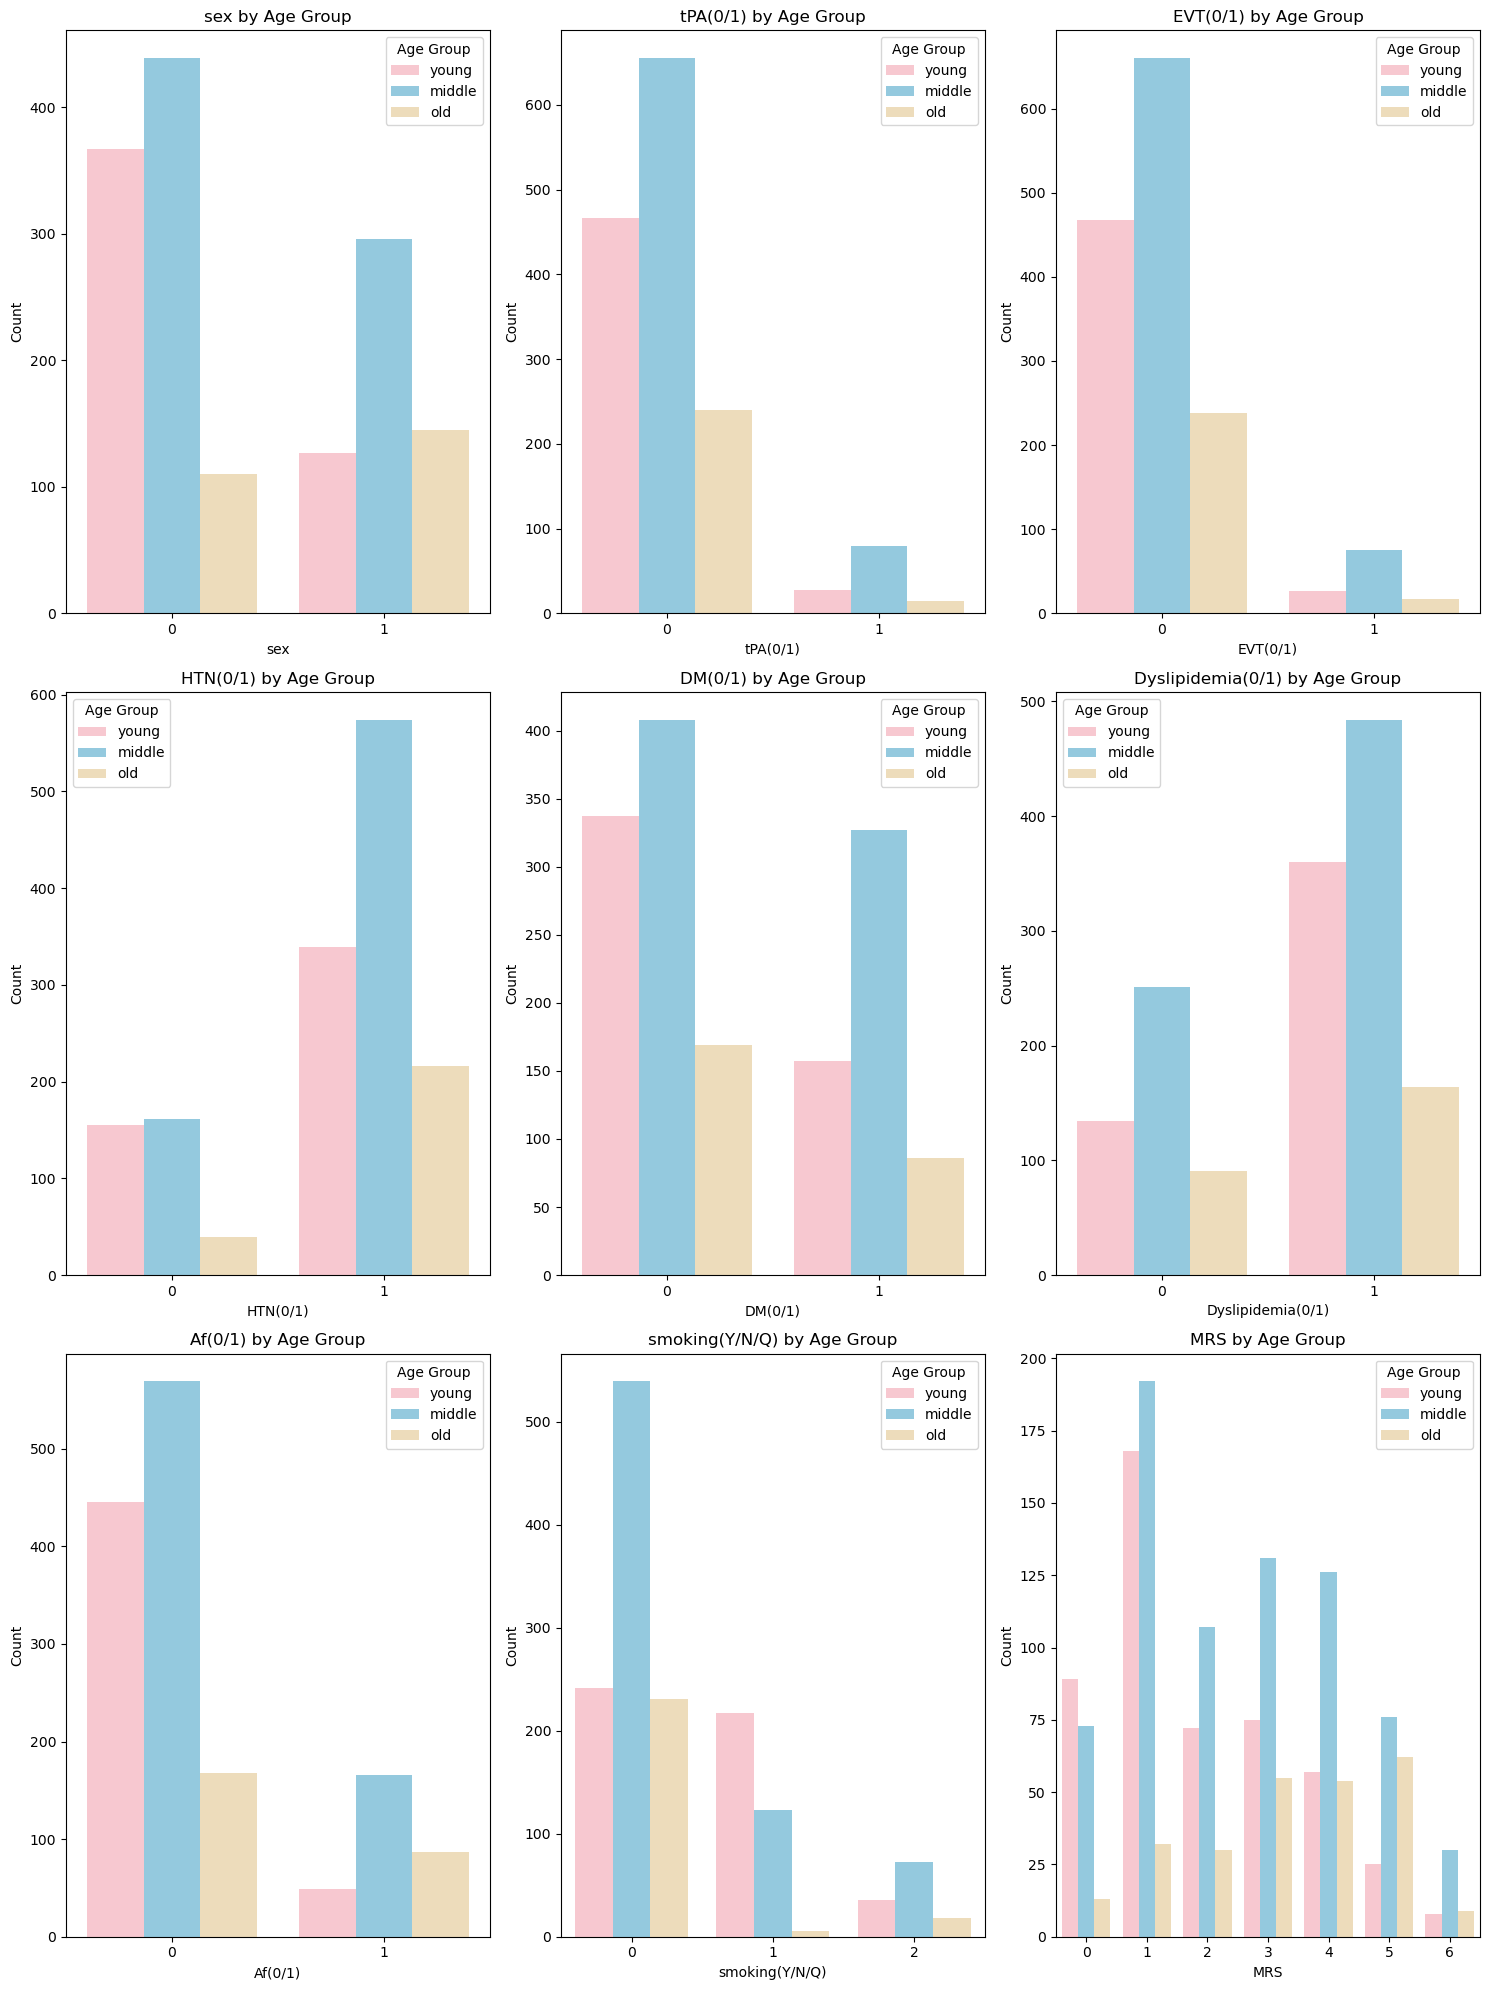

In [90]:
features = categorical_features
fig, axes = plt.subplots(3, 3, figsize=(15, 20))

for ax, feature in zip(axes.flatten(), features):
    sns.countplot(
        data=df_combined,
        x=feature,
        hue='age_group',
        # palette=['#ff9a8a', '#fbdd7e', '#a2cffe'],
        palette=['pink', 'skyblue', 'wheat'],
        ax=ax
    )
    ax.set_title(f'{feature} by Age Group')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')
    ax.legend(title='Age Group')

plt.tight_layout()
plt.show()

In [101]:
from scipy.stats import chi2_contingency, fisher_exact

cat_results = []
for feature in categorical_features:
    ctab = pd.crosstab(df_combined['age_group'], df_combined[feature])
    
    # Check expected counts
    chi2, p, dof, expected = chi2_contingency(ctab)
    if (expected < 5).any() and ctab.shape == (2, 2):
        # Use Fisher’s exact for 2x2
        _, p = fisher_exact(ctab)
        test_name = "Fisher's Exact"
    else:
        test_name = "Chi-square"
    
    cat_results.append({'Feature': feature, 'Test': test_name, 'p-value': p})

cat_results_df = pd.DataFrame(cat_results).round(4)
print(cat_results_df)

             Feature        Test  p-value
0                sex  Chi-square   0.0000
1           tPA(0/1)  Chi-square   0.0016
2           EVT(0/1)  Chi-square   0.0076
3           HTN(0/1)  Chi-square   0.0000
4            DM(0/1)  Chi-square   0.0000
5  Dyslipidemia(0/1)  Chi-square   0.0140
6            Af(0/1)  Chi-square   0.0000
7     smoking(Y/N/Q)  Chi-square   0.0000
8                MRS  Chi-square   0.0000


In [119]:
import numpy as np
import pandas as pd
from scipy.stats import shapiro, f_oneway, kruskal, chi2_contingency, fisher_exact

def fmt_p(p):
    if pd.isna(p): return ""
    return "< 0.001" if p < 0.001 else f"{p:.3f}".lstrip("0")

def fmt_mean_sd(x):
    return f"{np.nanmean(x):.1f} ± {np.nanstd(x, ddof=1):.1f}"

def fmt_median_iqr(x):
    q1, q3 = np.nanpercentile(x, [25, 75])
    return f"{np.nanmedian(x):.1f} [{q1:.1f}–{q3:.1f}]"

def check_normal(df, feature, group_col, groups):
    for g in groups:
        vals = df.loc[df[group_col]==g, feature].dropna()
        if len(vals)<3: return False
        stat, p = shapiro(vals) if len(vals)<=5000 else (None,1)
        if p<=0.05: return False
    return True

def build_baseline_table(df, cont_features, cat_features, group_col="age_group", group_order=None, export_path=None):

    if group_order is None:
        groups = df[group_col].dropna().unique().tolist()
    else:
        groups = group_order
    Ns = df[group_col].value_counts().reindex(groups).fillna(0).astype(int)
    headers = [f"{g} (n = {Ns[g]})" for g in groups]

    rows=[]
    # continuous
    for f in cont_features:
        normal = check_normal(df,f,group_col,groups)
        vals=[df.loc[df[group_col]==g,f].dropna() for g in groups]
        test="ANOVA" if normal else "Kruskal–Wallis"
        if normal:
            stat,p=f_oneway(*vals)
            disp=[fmt_mean_sd(v) for v in vals]
        else:
            stat,p=kruskal(*vals)
            disp=[fmt_median_iqr(v) for v in vals]
        row={"Variable":f,"Type":"Continuous",**dict(zip(headers,disp)),"Test":test,"p-value":fmt_p(p)}
        rows.append(row)

    # categorical
    for f in cat_features:
        tab=pd.crosstab(df[group_col],df[f])
        chi2,p,_,exp=chi2_contingency(tab)
        test="Chi-square"
        if (exp<5).any() and tab.shape==(2,2):
            from scipy.stats import fisher_exact
            _,p=fisher_exact(tab)
            test="Fisher’s exact"
        for level in tab.columns:
            r={"Variable":f" {f} = {level}","Type":"Categorical","Test":test,"p-value":fmt_p(p)}
            for g,h in zip(groups,headers):
                n=int(tab.loc[g,level]) if g in tab.index else 0
                total=Ns[g]
                perc=100*n/total if total>0 else np.nan
                r[h]=f"{n} ({perc:.1f})" if np.isfinite(perc) else ""
            rows.append(r)

    tbl=pd.DataFrame(rows)
    cols=["Variable","Type"]+headers+["Test","p-value"]
    tbl=tbl.reindex(columns=cols)

    # Optional export
    if export_path:
        if export_path.lower().endswith(".xlsx"):
            tbl.to_excel(export_path, index=False)
        else:
            tbl.to_csv(export_path, index=False)

    
    return tbl

In [121]:
df_combined['age_group'] = pd.Categorical(df_combined['age_group'],
                                          categories=['young','middle','old'],
                                          ordered=True)

table = build_baseline_table(df_combined, cont_features, categorical_features,
                             group_col='age_group',
                             group_order=['young','middle','old'],
                             export_path='baseline_table.xlsx')

display(table)
# table.to_excel("Baseline_APA_NEJM_style.xlsx", index=False)

,Variable,Type,young (n = 494),middle (n = 735),old (n = 255),Test,p-value
0,age,Continuous,56.0 [50.0–61.0],72.0 [69.0–76.0],85.0 [83.0–88.0],Kruskal–Wallis,< 0.001
1,HLOS,Continuous,8.0 [6.0–13.0],9.0 [6.0–21.0],12.0 [7.0–24.0],Kruskal–Wallis,< 0.001
2,NIHSS,Continuous,3.0 [1.0–5.0],3.0 [1.0–10.0],4.0 [2.0–13.0],Kruskal–Wallis,< 0.001
3,LDL,Continuous,113.0 [88.5–143.2],102.0 [75.0–126.0],101.7 [73.4–124.6],Kruskal–Wallis,< 0.001
4,cholesterol,Continuous,185.0 [158.0–219.0],175.0 [143.0–200.0],169.0 [137.5–198.0],Kruskal–Wallis,< 0.001
5,TG,Continuous,115.0 [83.0–161.8],98.0 [72.0–134.0],85.0 [63.0–108.5],Kruskal–Wallis,< 0.001
6,Cre,Continuous,0.9 [0.7–1.1],0.9 [0.8–1.2],1.0 [0.8–1.3],Kruskal–Wallis,.003
7,SGPT,Continuous,23.5 [17.2–33.0],21.0 [16.0–29.0],17.0 [14.0–22.5],Kruskal–Wallis,< 0.001
8,HbA1c,Continuous,5.7 [5.4–6.7],6.0 [5.6–6.8],5.8 [5.5–6.3],Kruskal–Wallis,< 0.001
9,sex = 0,Categorical,367 (74.3),439 (59.7),110 (43.1),Chi-square,< 0.001


## 不管連續還是非連續的 features 跑統計出來都說 there's a sig difference between diff age groups 但是看 boxplot 來比較 medians between different age groups 似乎又覺得沒有太大差別，於是做一下確認。

### 🧩 為什麼會這樣

#### 1️⃣ Kruskal–Wallis 對離群值非常敏感
這個檢定不是比較平均數，而是比較「rank（秩）」的分布。
如果某一組有幾個極高或極低的值，整組的 rank 分布就會被拉開。
→ 在樣本又小的情況下，這幾個 outliers 的影響會被放大，造成假顯著。

#### 2️⃣ 三組樣本不平衡會破壞秩的比較
Kruskal–Wallis 假設各組樣本數「大致接近」；
當某組人數特別多或特別少，整體 rank 分配不再均勻，也容易造成錯誤的 p 值。

#### 3️⃣ p 值對樣本數的解釋力弱
當樣本少時，p 值其實不太穩定（小樣本的檢定力低），
所以只要幾個 extreme value，就能讓檢定誤以為「差異顯著」。

In [124]:
# 1. 看中位數差距 (實際差多少)：計算各組中位數與百分比差距

for feature in cont_features:
    meds = df_combined.groupby('age_group')[feature].median()
    min_med = meds.min()
    max_med = meds.max()
    diff = max_med - min_med
    pct_diff = (diff / min_med * 100) if min_med != 0 else np.nan
    print(f"{feature}: medians = {meds.to_dict()}, "
          f"range = {diff:.2f}, "
          f"percent_diff = {pct_diff:.1f}%")

age: medians = {'young': 56.0, 'middle': 72.0, 'old': 85.0}, range = 29.00, percent_diff = 51.8%
HLOS: medians = {'young': 8.0, 'middle': 9.0, 'old': 12.0}, range = 4.00, percent_diff = 50.0%
NIHSS: medians = {'young': 3.0, 'middle': 3.0, 'old': 4.0}, range = 1.00, percent_diff = 33.3%
LDL: medians = {'young': 112.95, 'middle': 102.0, 'old': 101.7}, range = 11.25, percent_diff = 11.1%
cholesterol: medians = {'young': 185.0, 'middle': 175.0, 'old': 169.0}, range = 16.00, percent_diff = 9.5%
TG: medians = {'young': 115.0, 'middle': 98.0, 'old': 85.0}, range = 30.00, percent_diff = 35.3%
Cre: medians = {'young': 0.92, 'middle': 0.95, 'old': 1.0}, range = 0.08, percent_diff = 8.7%
SGPT: medians = {'young': 23.5, 'middle': 21.0, 'old': 17.0}, range = 6.50, percent_diff = 38.2%
HbA1c: medians = {'young': 5.7, 'middle': 6.0, 'old': 5.8}, range = 0.30, percent_diff = 5.3%


/var/folders/v7/p572dhnj3hnghq8_3m4f2xpc0000gn/T/ipykernel_53737/378407840.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  meds = df_combined.groupby('age_group')[feature].median()


### 這樣就能直觀看到：

每個變數三組的中位數

最大與最小中位數之間的絕對差

以及以最小中位數為基準的「百分比差距」

#### 💡 一般來說，如果差距小於 10%，而且樣本又小、outlier 又多，
#### 即使 p < 0.05，大多也只是「統計顯著但實際差異極小」。

In [125]:
# 2. 計算效應量 epsilon squared (ε²)
from scipy.stats import kruskal
def epsilon_squared_kruskal(*groups):
    k = len(groups)
    N = sum(len(g) for g in groups)
    H, _ = kruskal(*groups)
    return (H - k + 1) / (N - k)

for feature in cont_features:
    groups = [df_combined.loc[df_combined['age_group']==g, feature].dropna() for g in ['young','middle','old']]
    eps = epsilon_squared_kruskal(*groups)
    print(f"{feature}: ε² = {eps:.3f}")

age: ε² = 0.837
HLOS: ε² = 0.024
NIHSS: ε² = 0.017
LDL: ε² = 0.024
cholesterol: ε² = 0.022
TG: ε² = 0.049
Cre: ε² = 0.006
SGPT: ε² = 0.045
HbA1c: ε² = 0.010


### → 如果 ε² < 0.06，大多可以視為「雖統計顯著但實質差異很小」。
### 因為全部都小於 0.06，因此應該可以說族群間的分布並無 significant difference


#### Because all continuous variables were non-normally distributed, differences among age groups were assessed using the Kruskal–Wallis H test. Post-hoc pairwise comparisons with Bonferroni-adjusted Dunn tests showed that median ________ (feature name) and ________ (another feature name) were significantly higher in the (younger or middle or older) group compared with the (younger or middle or older) group (p < 0.01).

#### However, although statistical tests indicated significant differences among age groups for most continuous variables (Kruskal–Wallis test, p < 0.05), inspection of boxplots revealed overlapping medians and numerous outliers. Given the small and unequal sample sizes, these results likely reflect statistical rather than clinically meaningful differences. In addition to that, effect sizes (ε²) were generally small, indicating that these differences may not be clinically substantial.